1. Installing Libraries

In [1]:
!pip install langchain==0.3.27
!pip install langchain-core==0.3.72
!pip install langchain-community==0.3.27
!pip install langgraph==0.6.2
!pip install google-genai
!pip install langchain-google-genai


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 9.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/813.9 kB ? eta -:--:--
   ---------------------------------------- 813.9/813.9 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.86
    Uninstalling langchain-core-0.3.86:
      Successfully uninstalled langchain-core-0.3.86


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-text-splitters 0.3.11 requires langchain-core<2.0.0,>=0.3.75, but you have langchain-core 0.3.72 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached langchain_core-0.3.86-py3-none-any.whl.metadata (3.2 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   --------------------------------- ------ 2.1/2.5 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 8.1 MB/s eta 0:00:00
Using cached langchain_core-0.3.86-py3-none-any.whl (461 kB)
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.72
    Uninstalling langchain-core-0.3.72:
      Successfully uninstalled langchain-core-0.3.72



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/572.1 kB ? eta -:--:--
   ---------------------------------------- 572.1/572.1 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.86
    Uninstalling langchain-core-0.3.86:
      Successfully uninstalled langchain-core-0.3.86


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.6.6 which is incompatible.
langchain-community 0.3.27 requires langchain-core<1.0.0,>=0.3.66, but you have langchain-core 1.6.6 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. Importing Libraries

In [2]:
import os
import json
from typing import TypedDict, List
# LLM
from langchain_core.tools import Tool
from langchain_community.utilities import SerpAPIWrapper
from langgraph.graph import StateGraph, END, START

c:\Users\shiva\AppData\Local\Programs\Python\Python312\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


3. Creating Resource Pool

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

In [9]:
os.environ["GEMINI_API_KEY"] = "AQ.Ab8RN6INa204Ny5JO4psZAvtMcK_glSK5waoQq4Q0EAucZUvkQ"

In [14]:
MEMORY_FILE = "agent_memory.json"
class SharedResourcePool:
    def __init__(self):
        # Initialised LLM With Specific Parameters(temprature, top_p)
        self.llm = ChatGoogleGenerativeAI(model ="gemini-flash-lite-latest",
                             temperature=0.7,
                             max_output_tokens=1024,
                             google_api_key=os.environ['GEMINI_API_KEY'])
 
        # Call _load to laod the filr from thr memory
        self.memory: List[str] = self._load_memory()
        
    @staticmethod
    def _safe_eval(expr: str) -> str:
        try:
            return str(eval(expr))
        except Exception as e:
            return f"Error evaluating expression: {e}"
 
    def _load_memory(self) -> List[str]:  #Load The Memory
        if os.path.exists(MEMORY_FILE):
            with open(MEMORY_FILE, "r") as f:
              return json.load(f)
        else:
            return []
 
    def remember(self, note: str):       #Append The Memory
        self.memory.append(note)
        with open(MEMORY_FILE, "w") as f:
            json.dump(self.memory, f, indent = 2)
 
    def recall(self, last_n: int = 5) -> str: # Recall The Memory
        if not self.memory:
            return "(no earlier notes)"
        return "\n".join(self.memory[-last_n:])
 

In [15]:
# Initialize the shared resource pool
resource_pool = SharedResourcePool()

4. Create Graph State

In [16]:
class AgentState(TypedDict):
    query: str
    intent: str
    agent_answer: str
    final_answer: str

    cart: List[dict]
    order_id: str
    customer_name: str

    evaluation: dict
    retry_count: int

5. Creating Coffee Shop Menu

In [17]:
coffee_menu = {
    "latte": {
        "name": "Latte",
        "sizes": {
            "small": 3.50,
            "medium": 4.00,
            "large": 4.50
        },
        "milks": ["whole", "skim", "oat", "almond"],
        "extras": ["extra shot", "vanilla", "caramel"],
        "available": True
    },

    "cappuccino": {
        "name": "Cappuccino",
        "sizes": {
            "small": 3.25,
            "medium": 3.75,
            "large": 4.25
        },
        "milks": ["whole", "skim", "oat", "almond"],
        "extras": ["extra shot", "vanilla"],
        "available": True
    },

    "americano": {
        "name": "Americano",
        "sizes": {
            "small": 2.75,
            "medium": 3.25,
            "large": 3.75
        },
        "milks": ["whole", "skim", "oat", "almond"],
        "extras": ["extra shot"],
        "available": True
    },

    "caramel macchiato": {
        "name": "Caramel Macchiato",
        "sizes": {
            "small": 4.25,
            "medium": 4.75,
            "large": 5.25
        },
        "milks": ["whole", "skim", "oat", "almond"],
        "extras": ["extra shot", "vanilla", "caramel"],
        "available": False
    },

    "mocha": {
        "name": "Mocha",
        "sizes": {
            "small": 4.00,
            "medium": 4.50,
            "large": 5.00
        },
        "milks": ["whole", "skim", "oat", "almond"],
        "extras": ["extra shot", "vanilla"],
        "available": True
    }
}

6. Creating Tools
#### This Assignments Requires 6 tools
* get_menu
* check_availability
* validate_order
* update_cart
* calculate_total
* place_order

6.1 get_menu Tool

In [18]:
def get_menu(category=None):

    menu = {}

    for item, details in coffee_menu.items():

        if category is None or category.lower() in item.lower():

            menu[item] = {
                "name": details["name"],
                "sizes": details["sizes"],
                "milks": details["milks"],
                "extras": details["extras"],
                "available": details["available"]
            }

    return menu

In [19]:
print(get_menu())

{'latte': {'name': 'Latte', 'sizes': {'small': 3.5, 'medium': 4.0, 'large': 4.5}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot', 'vanilla', 'caramel'], 'available': True}, 'cappuccino': {'name': 'Cappuccino', 'sizes': {'small': 3.25, 'medium': 3.75, 'large': 4.25}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot', 'vanilla'], 'available': True}, 'americano': {'name': 'Americano', 'sizes': {'small': 2.75, 'medium': 3.25, 'large': 3.75}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot'], 'available': True}, 'caramel macchiato': {'name': 'Caramel Macchiato', 'sizes': {'small': 4.25, 'medium': 4.75, 'large': 5.25}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot', 'vanilla', 'caramel'], 'available': False}, 'mocha': {'name': 'Mocha', 'sizes': {'small': 4.0, 'medium': 4.5, 'large': 5.0}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot', 'vanilla'], 'available': True}}


6.2 check_availabilty Tool

In [21]:
def check_availability(item):

    if item not in coffee_menu:
        return False

    return coffee_menu[item]["available"]

In [22]:
print(check_availability("latte"))
print(check_availability("caramel macchiato"))

True
False


6.3 validate_order Tool

In [23]:
def validate_order(item, size, milk, extras):

    if item not in coffee_menu:
        return {
            "valid": False,
            "reason": f"{item} is not available on the menu."
        }

    product = coffee_menu[item]

    if not product["available"]:
        return {
            "valid": False,
            "reason": f"{product['name']} is currently out of stock."
        }

    if size not in product["sizes"]:
        return {
            "valid": False,
            "reason": f"{size} is not an available size."
        }

    if milk not in product["milks"]:
        return {
            "valid": False,
            "reason": f"{milk} milk is not available."
        }

    for extra in extras:

        if extra.lower() not in product["extras"]:
            return {
                "valid": False,
                "reason": f"{extra} is not available for {product['name']}."
            }

    return {
        "valid": True,
        "reason": "Order is valid."
    }

6.4 update_cart Tool

In [24]:
def update_cart(cart, action, item):

    updated_cart = cart.copy()
    if action == "add":
        updated_cart.append(item)
    elif action == "remove":
        updated_cart = [
            x for x in updated_cart
            if not (
                x["item"] == item["item"]
                and x["size"] == item["size"]
            )
        ]

    return updated_cart

6.5 calculate_total Tool

In [25]:
def calculate_total(cart):

    subtotal = 0

    for item in cart:

        subtotal += (
            item["price"] * item.get("quantity", 1)
        )

    tax = subtotal * 0.08

    total = subtotal + tax

    return {
        "subtotal": round(subtotal, 2),
        "tax": round(tax, 2),
        "total": round(total, 2)
    }

6.6 place_order Tool 

In [26]:
def place_order(cart, customer_name):

    if not cart:
        return {
            "success": False,
            "message": "Cannot place an empty order."
        }

    order_id = "ORD-" + str(
        1000 + len(cart)
    )

    return {
        "success": True,
        "order_id": order_id,
        "customer_name": customer_name,
        "pickup_time": "8 minutes"
    }

## Creating Agents

7. Planner Agent

In [73]:
def planner(state: AgentState) -> AgentState:

    prompt = f"""
You are the planner for an automated coffee ordering system.

Pick ONE agent to handle the customer query.

Options:

- menu_agent
  Use when the customer asks about the menu,
  coffee options, prices, sizes, milk types,
  add-ons or availability.

- order_agent
  Use when the customer wants to build,
  modify or customize an order.

- placement_agent
  Use when the customer wants to place,
  confirm or checkout an order.

Customer Query:
{state['query']}

Current Cart:
{state.get('cart', [])}

Agent name:"""

    choice = resource_pool.llm.invoke(prompt).content

    if choice not in (
        "menu_agent",
        "order_agent",
        "placement_agent"
    ):
        choice = "menu_agent"  # Default to menu_agent if the choice is invalid

    resource_pool.remember(
        f"Planner chose: {choice} for query: {state['query']}"
    )

    return {
        **state,
        "intent": choice
    }

In [62]:
def route_after_planner(state: AgentState) -> str:
    return state["intent"]

8. Menu Agent

In [82]:
def menu_agent(state: AgentState) -> AgentState:

    menu = get_menu()

    prompt = f"""
You are the Menu Agent for a coffee shop.

Answer the customer's question using ONLY the menu data below.

Do not invent:
- coffee items
- prices
- sizes
- milk types
- add-ons
- availability

Menu Data:
{menu}

Customer Query:
{state['query']}

Give a clear and concise response.
"""

    answer = resource_pool.llm.invoke(prompt).content
    print(menu)
    resource_pool.remember(
        f"Menu agent answered: {answer}"
    )

    return {
        **state,
        "agent_answer": answer
    }

9. Order Agent

In [69]:
def order_agent(state: AgentState) -> AgentState:

    query = state["query"]
    cart = state.get("cart", [])

    # Extract order information
    prompt = f"""
    You are the Order Agent for a coffee shop.
Extract the following information from the customer request:

item
size
milk
extras
quantity

Use NONE if information is missing.

Customer Request:
{query}

Return exactly:

item: ...
size: ...
milk: ...
extras: ...
quantity: ...
"""

    extracted = resource_pool.llm.invoke(prompt).content

    print("Extracted Order:")
    print(extracted)

    # Convert extracted information into simple values
    data = {}

    for line in extracted:
        if ":" in line:
            key, value = line.split(":", 1)
            data[key.strip().lower()] = value.strip()

    item = data.get("item")
    size = data.get("size")
    milk = data.get("milk")

    extras = data.get("extras", "NONE")

    if extras.upper() == "NONE":
        extras = []
    else:
        extras = [
            x.strip().lower()
            for x in extras.split(",")
        ]

    try:
        quantity = int(data.get("quantity", 1))
    except:
        quantity = 1

    # Missing item
    if not item or item.upper() == "NONE":
        return {
            **state,
            "agent_answer": "What coffee would you like to order?"
        }

    item = item.lower()

    # Check availability
    if not check_availability(item):
        return {
            **state,
            "agent_answer":
                f"Sorry, {item} is currently unavailable."
        }

    # Ask for missing size
    if not size or size.upper() == "NONE":
        return {
            **state,
            "agent_answer":
                "What size would you like?"
        }

    size = size.lower()

    # Ask for missing milk
    if not milk or milk.upper() == "NONE":
        return {
            **state,
            "agent_answer":
                "What type of milk would you like?"
        }

    milk = milk.lower()

    # Validate order
    validation = validate_order(
        item,
        size,
        milk,
        extras
    )

    if not validation["valid"]:
        return {
            **state,
            "agent_answer":
                f"Sorry, {validation['message']}"
        }

    # Create cart item
    cart_item = {
        "item": item,
        "size": size,
        "milk": milk,
        "extras": extras,
        "quantity": quantity
    }

    # Update cart
    updated_cart = update_cart(
        cart,
        "add",
        cart_item
    )

    # Calculate total
    total = calculate_total(updated_cart)

    answer = (
        f"Added {quantity} x {item} "
        f"({size}, {milk} milk).\n\n"
        f"Subtotal: ${total['subtotal']:.2f}\n"
        f"Tax: ${total['tax']:.2f}\n"
        f"Total: ${total['total']:.2f}\n\n"
        "Would you like anything else?"
    )

    return {
        **state,
        "cart": updated_cart,
        "agent_answer": answer
    }

10. Placement Agent

In [36]:
def placement_agent(state: AgentState) -> AgentState:

    cart = state.get("cart", [])
    query = state["query"]

    prompt = f"""
You are the Placement Agent.

Current Cart:
{cart}

Order Total:
{total}

Customer Query:
{state['query']}

If the customer has not confirmed the order,
ask for confirmation.

If the customer has confirmed the order,
the order can be placed.
"""

    answer = resource_pool.llm.invoke(prompt).content

    # Do not place an empty order
    if not cart:
        return {
            **state,
            "agent_answer":
                "Your cart is empty. Please add an item before placing an order."
        }

    # Calculate current order total
    total = calculate_total(cart)

    # Check customer confirmation
    confirmation_words = [
        "yes",
        "confirm",
        "confirmed",
        "go ahead",
        "place it",
        "place my order",
        "place the order"
    ]

    confirmed = any(
        word in query.lower()
        for word in confirmation_words
    )

    # Ask for confirmation
    if not confirmed:

        return {
            **state,
            "agent_answer": (
                f"Your order total is "
                f"${total['total']:.2f}.\n\n"
                "Would you like me to place the order?"
            )
        }

    # Place confirmed order
    customer_name = state.get(
        "customer_name",
        "Customer"
    )

    result = place_order(
        cart,
        customer_name
    )

    if not result["success"]:
        return {
            **state,
            "agent_answer": result["message"]
        }

    return {
        **state,
        "order_id": result["order_id"],
        "agent_answer": (
            "Your order has been placed successfully!\n\n"
            f"Order ID: {result['order_id']}\n"
            f"Total: ${total['total']:.2f}\n"
            f"Pickup Time: {result['pickup_time']}"
        )
    }

11. Evaluator Agent

In [56]:
def evaluator(state: AgentState) -> AgentState:

    prompt = f"""
You are the Evaluator Agent for a coffee shop system.

Evaluate the following response.

Customer Query:
{state['query']}

Agent Selected:
{state['intent']}

Agent Response:
{state['agent_answer']}

Check:

1. Correctness
2. Completeness
3. No hallucination
4. Correct intent

Return exactly:

VERDICT: approved
or
VERDICT: rejected

SCORE: 1-5

FEEDBACK: short explanation
"""

    response = resource_pool.llm.invoke(prompt).content

    print("Evaluation:")
    print(response)

    return {
        **state,
        "evaluation": response,
        "final_answer": state["agent_answer"]
    }

12. Creating Graph

In [83]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)

# Add nodes
graph.add_node("planner", planner)
graph.add_node("menu_agent", menu_agent)
graph.add_node("order_agent", order_agent)
graph.add_node("placement_agent", placement_agent)
graph.add_node("evaluator", evaluator)

# Start with Planner
graph.add_edge(START, "planner")

# Planner routes to the required agent
graph.add_conditional_edges(
    "planner",
    route_after_planner,
    {
        "menu_agent": "menu_agent",
        "order_agent": "order_agent",
        "placement_agent": "placement_agent"
    }
)

# Task agents go to Evaluator
graph.add_edge("menu_agent", "evaluator")
graph.add_edge("order_agent", "evaluator")
graph.add_edge("placement_agent", "evaluator")

# Evaluator ends the workflow
graph.add_edge("evaluator", END)

# Compile graph
app = graph.compile()

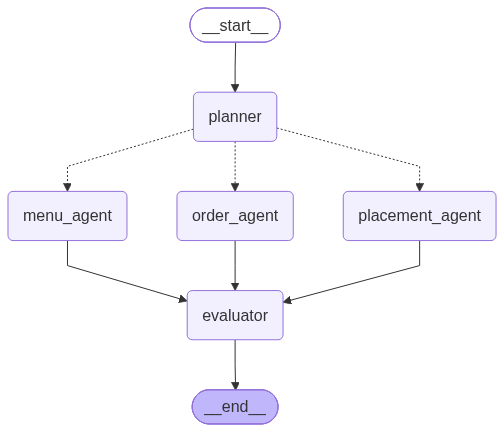

In [67]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

13. Giving Queries

In [84]:
query = "What coffees do you have?"
result = app.invoke(initial_state)

{'latte': {'name': 'Latte', 'sizes': {'small': 3.5, 'medium': 4.0, 'large': 4.5}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot', 'vanilla', 'caramel'], 'available': True}, 'cappuccino': {'name': 'Cappuccino', 'sizes': {'small': 3.25, 'medium': 3.75, 'large': 4.25}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot', 'vanilla'], 'available': True}, 'americano': {'name': 'Americano', 'sizes': {'small': 2.75, 'medium': 3.25, 'large': 3.75}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot'], 'available': True}, 'caramel macchiato': {'name': 'Caramel Macchiato', 'sizes': {'small': 4.25, 'medium': 4.75, 'large': 5.25}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot', 'vanilla', 'caramel'], 'available': False}, 'mocha': {'name': 'Mocha', 'sizes': {'small': 4.0, 'medium': 4.5, 'large': 5.0}, 'milks': ['whole', 'skim', 'oat', 'almond'], 'extras': ['extra shot', 'vanilla'], 'available': True}}
Evaluation:
[{'type':

In [85]:
print("Final Answer:")
print(result["final_answer"])

Final Answer:
[{'type': 'text', 'text': 'We have the following coffees available: Latte, Cappuccino, Americano, and Mocha. (Note: Caramel Macchiato is currently unavailable).', 'extras': {'signature': 'EmAKXgFpFH0TYVLPmBfIsV3j6GmTF4R8bKPGbuIWOPmVLnpcAnNvuhCpKma+HlZ9YU3vzfCsqifOxn7D+nzM0vZKfPD88bwc95bXaaNE7g/ItoABEfrTxV/OJ+VNF1BWgX4='}}]
